[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/colab-version/L04/L04_radial_basis_functions.ipynb)

# Radial Basis Function Networks
### MECH 559 - Systems Optimization - L04
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

This notebook builds an RBF interpolant by solving one linear system for the
weights, then explores how the kernel's spread parameter controls the
smoothness (and accuracy) of the fit.

## Learning objectives

By the end, you should be able to:

1. Build the interpolation matrix $\mathbf\Phi$ and solve $\mathbf\Phi\mathbf w=\mathbf y$ for the RBF weights.
2. Explain why the spread parameter is a complexity knob, and see the underfit/overfit extremes.
3. Select a spread by minimizing held-out RMSE.
4. Compare Gaussian, multiquadric, inverse multiquadric, and thin-plate-spline kernels.

We use the **Forrester function**, a standard 1-D surrogate-modelling benchmark:
$$f(x) = (6x-2)^2\sin(12x-4), \qquad x\in[0,1].$$

> **Classroom rhythm:** I will pause at each **Predict** prompt before running the next cell.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

rng = np.random.default_rng(559)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
COLORS = {"true": "#264653", "train": "#00798C", "fit": "#D1495B", "band": "#EDAE49", "alt": "#2A9D8F"}
print(f"Optional widgets available: {WIDGETS_AVAILABLE}")


def forrester(x):
    return (6 * x - 2) ** 2 * np.sin(12 * x - 4)


def lhs_1d(p, seed=0):
    sampler = qmc.LatinHypercube(d=1, seed=seed)
    return sampler.random(p).ravel()

Optional widgets available: True


---
## 1. Interpolation via one linear system

Place one radial basis function at each of the $p$ training points and sum
them: $\hat y(x)=\sum_{i=1}^p w_i\,\phi(|x-x_i|)$. Because the centers are
fixed at the training points, the interpolation conditions $\hat y(x_i)=y_i$
for $i=1,\dots,p$ give one linear system
$$\mathbf\Phi\mathbf w=\mathbf y, \qquad \Phi_{ij}=\phi(|x_i-x_j|),$$
which we solve directly -- there is no iterative "keep adding terms" step.

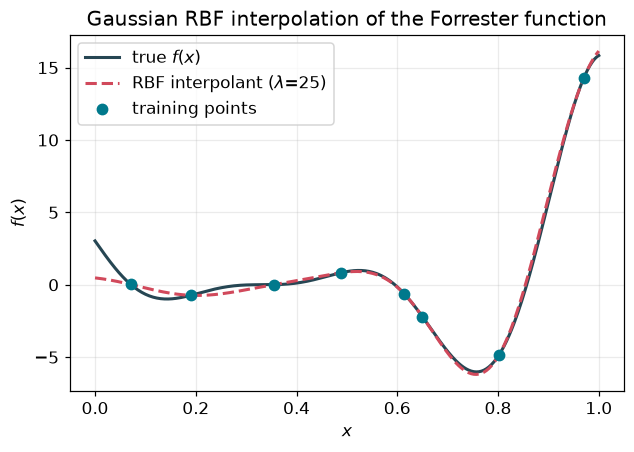

Interpolation confirmed: the fit passes exactly through every training point.


In [3]:
def gaussian_kernel(r, lam):
    return np.exp(-lam * r**2)


def rbf_fit(x_train, y_train, kernel, **kernel_kwargs):
    r = np.abs(x_train[:, None] - x_train[None, :])
    Phi = kernel(r, **kernel_kwargs)
    weights = np.linalg.solve(Phi, y_train)
    return weights


def rbf_predict(x_new, x_train, weights, kernel, **kernel_kwargs):
    r = np.abs(x_new[:, None] - x_train[None, :])
    Phi_new = kernel(r, **kernel_kwargs)
    return Phi_new @ weights


p = 8
x_train = lhs_1d(p, seed=3)
y_train = forrester(x_train)
x_dense = np.linspace(0, 1, 400)

lam = 25.0
weights = rbf_fit(x_train, y_train, gaussian_kernel, lam=lam)
y_hat = rbf_predict(x_dense, x_train, weights, gaussian_kernel, lam=lam)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(x_dense, forrester(x_dense), color=COLORS["true"], lw=2, label="true $f(x)$")
ax.plot(x_dense, y_hat, color=COLORS["fit"], lw=2, ls="--", label=f"RBF interpolant ($\\lambda$={lam:g})")
ax.scatter(x_train, y_train, color=COLORS["train"], zorder=5, s=45, label="training points")
ax.set(xlabel="$x$", ylabel="$f(x)$", title="Gaussian RBF interpolation of the Forrester function")
ax.legend(); plt.show()

assert np.allclose(rbf_predict(x_train, x_train, weights, gaussian_kernel, lam=lam), y_train, atol=1e-8)
print("Interpolation confirmed: the fit passes exactly through every training point.")

---
## 2. The spread parameter is a complexity knob

> **Predict:** does a *large* $\lambda$ (narrow bumps) or a *small* $\lambda$
> (wide, overlapping bumps) look more likely to overfit?

In [ ]:
def plot_spread_effect(lam=25.0):
    weights = rbf_fit(x_train, y_train, gaussian_kernel, lam=lam)
    y_hat = rbf_predict(x_dense, x_train, weights, gaussian_kernel, lam=lam)
    rmse = np.sqrt(np.mean((y_hat - forrester(x_dense)) ** 2))

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.plot(x_dense, forrester(x_dense), color=COLORS["true"], lw=2, label="true $f(x)$")
    ax.plot(x_dense, y_hat, color=COLORS["fit"], lw=2, ls="--", label="RBF interpolant")
    ax.scatter(x_train, y_train, color=COLORS["train"], zorder=5, s=45, label="training points")
    ax.set(xlabel="$x$", ylabel="$f(x)$", ylim=(-12, 22),
           title=f"spread $\\lambda$={lam:g}  (dense-grid RMSE={rmse:.2f})")
    ax.legend(); plt.show()


if WIDGETS_AVAILABLE:
    display(widgets.interactive(
        plot_spread_effect,
        lam=widgets.FloatLogSlider(value=25.0, base=10, min=-1, max=4, step=0.1, description="lambda"),
    ))
else:
    for lam_value in (0.5, 25.0, 5000.0):
        plot_spread_effect(lam_value)

interactive(children=(FloatLogSlider(value=25.0, description='lambda', min=-1.0), Output()), _dom_classes=('wi…

Very large $\lambda$ makes each bump so narrow that the interpolant collapses
to ~0 between training points (badly overfit, wild oscillation near the data);
very small $\lambda$ makes the bumps so wide that they blend into an almost
flat, oversmoothed curve (underfit). A good $\lambda$ sits in between.

> **Predict:** if we score $\lambda$ by RMSE on a held-out test set instead of
> the dense grid (which uses knowledge of the true function we would not have
> in practice), will we still see a U-shaped error curve?

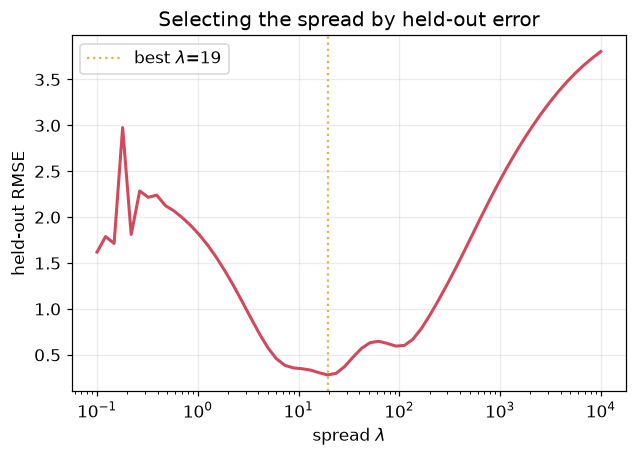

best spread by held-out RMSE: lambda=19.4, RMSE=0.281


In [5]:
x_test = rng.uniform(0, 1, size=200)
y_test = forrester(x_test)

lambdas = np.logspace(-1, 4, 60)
test_rmses = []
for lam_value in lambdas:
    weights = rbf_fit(x_train, y_train, gaussian_kernel, lam=lam_value)
    y_test_hat = rbf_predict(x_test, x_train, weights, gaussian_kernel, lam=lam_value)
    test_rmses.append(np.sqrt(np.mean((y_test_hat - y_test) ** 2)))
test_rmses = np.array(test_rmses)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.semilogx(lambdas, test_rmses, color=COLORS["fit"], lw=2)
best_lam = lambdas[np.argmin(test_rmses)]
ax.axvline(best_lam, color=COLORS["band"], ls=":", label=f"best $\\lambda$={best_lam:.2g}")
ax.set(xlabel=r"spread $\lambda$", ylabel="held-out RMSE", title="Selecting the spread by held-out error")
ax.legend(); plt.show()
print(f"best spread by held-out RMSE: lambda={best_lam:.3g}, RMSE={test_rmses.min():.3f}")

---
## 3. Kernel comparison

The Gaussian is only one choice of radial kernel $\phi$. We compare it against
the multiquadric, inverse multiquadric, and thin-plate-spline kernels (the
latter two need no shape parameter to tune).

kernel                        test RMSE
Gaussian (best lambda=19)         0.281
Multiquadric                      0.582
Inverse multiquadric              0.346
Thin-plate spline                 3.888


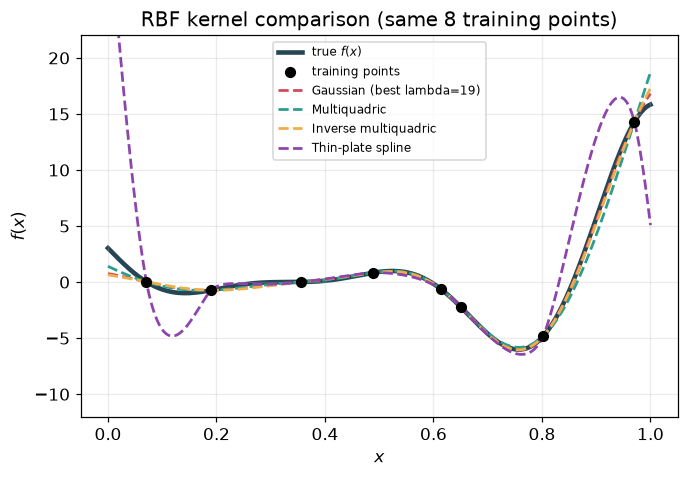

In [6]:
def multiquadric_kernel(r, c=0.3):
    return np.sqrt(r**2 + c**2)


def inverse_multiquadric_kernel(r, c=0.3):
    return 1.0 / np.sqrt(r**2 + c**2)


def thin_plate_kernel(r):
    with np.errstate(divide="ignore", invalid="ignore"):
        value = (r**2) * np.log(r)
    return np.nan_to_num(value, nan=0.0)


kernels = {
    f"Gaussian (best lambda={best_lam:.2g})": (gaussian_kernel, {"lam": best_lam}),
    "Multiquadric": (multiquadric_kernel, {}),
    "Inverse multiquadric": (inverse_multiquadric_kernel, {}),
    "Thin-plate spline": (thin_plate_kernel, {}),
}

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_dense, forrester(x_dense), color=COLORS["true"], lw=3, label="true $f(x)$", zorder=1)
ax.scatter(x_train, y_train, color="black", zorder=5, s=40, label="training points")

print(f"{'kernel':<28} {'test RMSE':>10}")
for (name, (kernel, kwargs)), color in zip(kernels.items(), ["#D1495B", "#2A9D8F", "#EDAE49", "#8E44AD"]):
    weights = rbf_fit(x_train, y_train, kernel, **kwargs)
    y_hat = rbf_predict(x_dense, x_train, weights, kernel, **kwargs)
    y_test_hat = rbf_predict(x_test, x_train, weights, kernel, **kwargs)
    test_rmse = np.sqrt(np.mean((y_test_hat - y_test) ** 2))
    ax.plot(x_dense, y_hat, lw=1.8, ls="--", color=color, label=name)
    print(f"{name:<28} {test_rmse:>10.3f}")

ax.set(xlabel="$x$", ylabel="$f(x)$", ylim=(-12, 22), title="RBF kernel comparison (same 8 training points)")
ax.legend(fontsize=8); plt.show()

## Takeaways

1. Fixing the RBF centers at the training points turns fitting into a single
   linear solve $\mathbf\Phi\mathbf w=\mathbf y$ -- structurally identical to
   the Kriging system in the next notebook.
2. The spread parameter $\lambda$ is a complexity knob: too large overfits
   (narrow, wild bumps), too small underfits (oversmoothed).
3. As always, $\lambda$ should be chosen by held-out (or cross-validated)
   error, not by how well the fit passes through the training points --
   interpolation always does that exactly, regardless of $\lambda$.
4. Different kernel shapes give different biases; on this benchmark the tuned
   Gaussian was competitive with the shape-parameter-free alternatives.

## Classroom exercises

1. Reduce `p` (number of training points) to 5 and re-run the spread sweep.
   Does the best $\lambda$ shift?
2. Tune the shape parameter `c` of the multiquadric kernel the same way we
   tuned the Gaussian's $\lambda$, using held-out RMSE.
3. Replace the Forrester function with a much smoother one (e.g. a plain
   quadratic). Does the spread parameter still matter as much?